# PCA and clustering on the digits

The 8x8 digits live in 64 dimensions. Here I project them to two principal components to
look at the structure, then cluster with k-means and a Gaussian mixture and check how well
unsupervised labels line up with the true digits.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.metrics import adjusted_rand_score

from scratchlearn.decomposition import PCA
from scratchlearn.cluster import KMeans, GaussianMixture

X, y = load_digits(return_X_y=True)
X = X / 16.0
X.shape

(1797, 64)

variance explained by 2 components: 28.5%


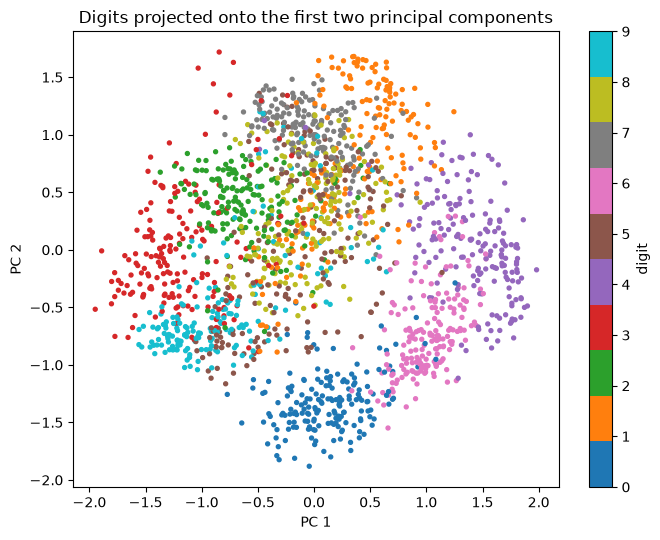

In [2]:
pca2 = PCA(n_components=2)
Z = pca2.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", s=8)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("Digits projected onto the first two principal components")
fig.colorbar(scatter, label="digit")
plt.tight_layout()

print("variance explained by 2 components:",
      f"{pca2.explained_variance_ratio_.sum():.1%}")

Two components keep barely a quarter of the variance, so clustering directly in 2-D
would throw information away. Instead I reduce to 16 components and cluster there, using
the 2-D projection purely for display.

In [3]:
pca16 = PCA(n_components=16)
Z16 = pca16.fit_transform(X)
print("variance kept by 16 components:",
      f"{pca16.explained_variance_ratio_.sum():.1%}")

km = KMeans(n_clusters=10, random_state=0).fit(Z16)
gmm = GaussianMixture(n_components=10, random_state=0).fit(Z16)

print("adjusted Rand index vs true digits")
print(f"  k-means:          {adjusted_rand_score(y, km.labels_):.3f}")
print(f"  Gaussian mixture: {adjusted_rand_score(y, gmm.predict(Z16)):.3f}")

variance kept by 16 components: 84.9%


adjusted Rand index vs true digits
  k-means:          0.658
  Gaussian mixture: 0.743


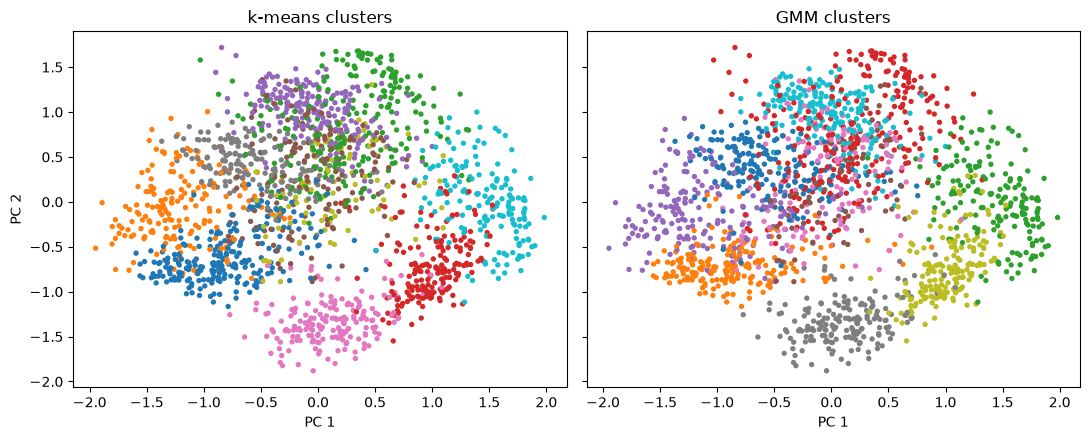

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, labels, title in [
    (axes[0], km.labels_, "k-means clusters"),
    (axes[1], gmm.predict(Z16), "GMM clusters"),
]:
    ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=8)
    ax.set_title(title)
    ax.set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
plt.tight_layout()

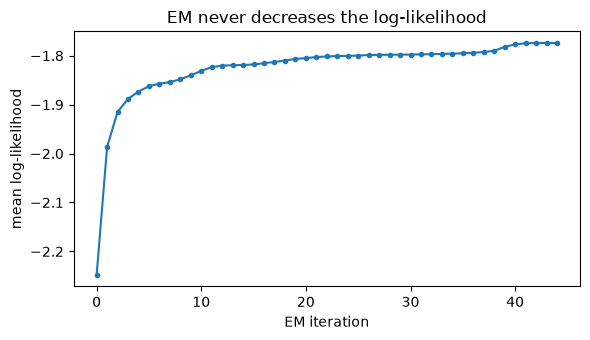

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(gmm.log_likelihood_history_, marker=".")
ax.set_xlabel("EM iteration")
ax.set_ylabel("mean log-likelihood")
ax.set_title("EM never decreases the log-likelihood")
plt.tight_layout()

The monotone curve shows the EM guarantee from `docs/derivations/gmm_em.md`. Each E-step makes the evidence lower bound tight, each M-step raises it.